# Model Distillation & Quantization

The objective of this part is to reduce the computational requirements of our best-performing sarcasm classifier so that it can be deployed cheaply and at scale, and to measure rigorously what that compression costs us in predictive quality. Throughout Parts 1-3 we established a clear ladder of performance: a stratified-random baseline at macro F1 = 0.5108, rule-based VADER classifiers that could not beat it (best macro F1 = 0.4461), and finally a family of DistilBERT models. The strongest of these, a fully fine-tuned (unfrozen) DistilBERT trained on the whole training set, reached **macro F1 = 0.733 and accuracy = 0.744** (Part 3), our best result overall and the model we now take as the starting point for compression.

### a) Model Distillation / Quantization

#### Setup, configuration and data

Parts 2-3 padded every sequence to the model maximum; here we tokenise with truncation at `max_len = 256` and let a dynamic collator pad each batch only to its own longest sequence. Measured on our corpus with the DistilBERT tokenizer, the sub-word length distribution has median 40, 95th percentile 108 and a maximum of 273 tokens, so `max_len = 256` truncates only **0.03%** of sentences (a single example) while making both training and the latency benchmark substantially cheaper than a fixed 512. This is effectively lossless and keeps the comparison fair across all variants.

In [1]:
import os, time, copy, tempfile, random, warnings, gc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DistilBertConfig, DistilBertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback, set_seed
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tokenize.treebank import TreebankWordDetokenizer
import psutil
from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

def lock_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    set_seed(seed)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

CONFIG = {
    "seed": 7994,
    "max_len": 256,
    "model_name": "distilbert-base-uncased",
    "teacher_dir": "../models/teacher_distilbert",
    "student_layers": 3,
    "student_epochs": 2,
    "student_lr": 5e-5,
    "kd_temperature": 2.0,
    "kd_alpha": 0.5,
    "batch_size": 8,
    "eval_batch": 64,
}
lock_seeds(CONFIG["seed"])
print(f"Device: {DEVICE} | torch {torch.__version__}")

c:\Users\qwert\Documents\AdvancedNLP\Final_Project\sarcasm_text_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | torch 2.12.0+cpu


In [2]:
df = pd.read_csv("../data/cleaned_sarcasm_dataset.csv")
label_map = {"Non-Sarcastic": 0, "Sarcastic": 1}

train_df = df[df["split"] == "train"].copy()
test_df  = df[df["split"] == "test"].copy()
train_df["labels"] = train_df["label"].astype(str).map(label_map)
test_df["labels"]  = test_df["label"].astype(str).map(label_map)

print(f"Train: {len(train_df)}   Test: {len(test_df)}")
print("Test class balance:")
print(test_df["labels"].value_counts().rename({0: 'Non-Sarcastic', 1: 'Sarcastic'}))

Train: 2936   Test: 734
Test class balance:
labels
Sarcastic        462
Non-Sarcastic    272
Name: count, dtype: int64


In [3]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc = tokenizer(list(texts), truncation=True, max_length=max_len)
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {}
        for k in self.enc:
            item[k] = self.enc[k][i]
        item["labels"] = int(self.labels[i])
        return item

train_ds = SarcasmDataset(train_df["Sentence"], train_df["labels"], tokenizer, CONFIG["max_len"])
test_ds  = SarcasmDataset(test_df["Sentence"],  test_df["labels"],  tokenizer, CONFIG["max_len"])
collator = DataCollatorWithPadding(tokenizer)
test_texts  = test_df["Sentence"].tolist()
test_labels = np.array(test_df["labels"].tolist())

#### Shared evaluation utilities

In [5]:
def disk_size_mb(model):
    fd, path = tempfile.mkstemp(suffix=".pt")
    os.close(fd)
    try:
        torch.save(model.state_dict(), path)
        return os.path.getsize(path) / 1e6
    finally:
        if os.path.exists(path):
            os.remove(path)

def n_params(model):
    total = 0
    for p in model.parameters():
        total += p.numel()
    return total

@torch.no_grad()
def predict_logits(model, dataset, device, batch_size=64):
    model.eval().to(device)
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    out = []
    for batch in loader:
        inp = {}
        for k, v in batch.items():
            if k in ("input_ids", "attention_mask"):
                inp[k] = v.to(device)
        out.append(model(**inp).logits.float().cpu())
    return torch.cat(out).numpy()

def evaluate(model, dataset, labels, device, name=""):
    logits = predict_logits(model, dataset, device)
    preds = logits.argmax(-1)
    probs = torch.softmax(torch.tensor(logits), -1).numpy()
    per_class = f1_score(labels, preds, average=None, zero_division=0)
    res = {
        "name": name,
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_nonsarc": per_class[0],
        "f1_sarc":    per_class[1],
    }
    return res, preds, probs

@torch.no_grad()
def benchmark_latency(model, texts, tokenizer, device, max_len, n_warmup=5, n_runs=120):
    model.eval().to(device)
    sample = texts[:n_runs] if len(texts) >= n_runs else texts
    def run_one(t):
        enc = tokenizer(t, truncation=True, max_length=max_len, return_tensors="pt")
        moved = {}
        for k, v in enc.items():
            moved[k] = v.to(device)
        model(**moved)
    for t in sample[:n_warmup]:
        run_one(t)
    times = []
    for t in sample:
        s = time.perf_counter(); run_one(t); times.append((time.perf_counter() - s) * 1000)
    return float(np.mean(times)), float(np.std(times))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.asarray(logits).argmax(-1)
    return {"accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro", zero_division=0)}

@torch.no_grad()
def measure_efficiency(model, dataset, device, batch_size=64):
    model.eval().to(device)
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    proc = psutil.Process(os.getpid())
    gc.collect()
    ram_base = proc.memory_info().rss / 1e6 if proc else float("nan")
    ram_peak = ram_base
    tracker = None
    try:
        tracker = EmissionsTracker(project_name="part4_sarcasm", measure_power_secs=1, save_to_file=False, allow_multiple_runs=True)
        tracker.start()
    except Exception:
        tracker = None
    n = 0
    t0 = time.perf_counter()
    for batch in loader:
        inp = {}
        for k, v in batch.items():
            if k in ("input_ids", "attention_mask"):
                inp[k] = v.to(device)
        model(**inp)
        n += inp["input_ids"].shape[0]
        if proc:
            ram_peak = max(ram_peak, proc.memory_info().rss / 1e6)
    elapsed = time.perf_counter() - t0
    carbon_kg = float("nan")
    if tracker is not None:
        try:
            carbon_kg = float(tracker.stop())
        except Exception:
            carbon_kg = float("nan")
    return {
        "throughput_sps": (n / elapsed) if elapsed > 0 else float("nan"),
        "ram_peak_mb": ram_peak,
        "ram_used_mb": (ram_peak - ram_base) if proc else float("nan"),
        "carbon_kg": carbon_kg,
        "n_eval": n,
    }

#### The teacher: our best-performing model

In [14]:
teacher = AutoModelForSequenceClassification.from_pretrained("../results_unfrozen_100/checkpoint-734")

results = {}

teacher_res, teacher_preds, teacher_probs = evaluate(teacher, test_ds, test_labels, DEVICE, "Teacher (DistilBERT fp32)")
teacher_res["params"]   = n_params(teacher)
teacher_res["size_mb"]  = disk_size_mb(teacher)
teacher_res["latency_ms"], teacher_res["latency_std"] = benchmark_latency(teacher, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
results["teacher"] = teacher_res

print(classification_report(test_labels, teacher_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
summary = {}
for k, v in teacher_res.items():
    if isinstance(v, float):
        summary[k] = round(v, 4)
    else:
        summary[k] = v
print(summary)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8653.02it/s]


               precision    recall  f1-score   support

Non-Sarcastic       0.63      0.73      0.68       272
    Sarcastic       0.82      0.75      0.79       462

     accuracy                           0.74       734
    macro avg       0.73      0.74      0.73       734
 weighted avg       0.75      0.74      0.75       734

{'name': 'Teacher (DistilBERT fp32)', 'accuracy': 0.7439, 'macro_f1': 0.7327, 'macro_precision': 0.7296, 'macro_recall': 0.7406, 'f1_nonsarc': np.float64(0.6781), 'f1_sarc': np.float64(0.7873), 'params': 66955010, 'size_mb': 267.8609, 'latency_ms': 16.3472, 'latency_std': 3.7612}


#### Quantization (dynamic, INT8)

Quantization is the cheaper of our two techniques because it requires no retraining and no labelled data. A fine-tuned transformer spends almost all of its weights and arithmetic in nn.Linear layers. Post-training dynamic quantization stores those weight matrices as 8-bit integers and quantizes the activations on the fly at inference time, computing the per-tensor scale from the observed activation range of each batch. We choose the dynamic variant over the two alternatives deliberately: static post-training quantization would require a calibration pass over representative data to fix activation ranges in advance, and Quantization-Aware Training would require us to re-run the full fine-tuning with simulated int8.

In [15]:
teacher_cpu = copy.deepcopy(teacher).to("cpu").eval()
quantized = torch.quantization.quantize_dynamic(teacher_cpu, {torch.nn.Linear}, dtype=torch.qint8)

quant_res, quant_preds, quant_probs = evaluate(quantized, test_ds, test_labels, torch.device("cpu"), "Quantized (DistilBERT int8)")
quant_res["params"]  = n_params(teacher)
quant_res["size_mb"] = disk_size_mb(quantized)
quant_res["latency_ms"], quant_res["latency_std"] = benchmark_latency(quantized, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
results["quantized"] = quant_res

print("QUANTIZED (int8, dynamic)")
print(classification_report(test_labels, quant_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
print(f"Size: {teacher_res['size_mb']:.1f} MB -> {quant_res['size_mb']:.1f} MB ({teacher_res['size_mb']/quant_res['size_mb']:.2f}x smaller)")
print(f"Latency: {teacher_res['latency_ms']:.1f} ms -> {quant_res['latency_ms']:.1f} ms ({teacher_res['latency_ms']/quant_res['latency_ms']:.2f}x faster)")
print(f"Macro-F1: {teacher_res['macro_f1']:.4f} -> {quant_res['macro_f1']:.4f}")

QUANTIZED (int8, dynamic)
               precision    recall  f1-score   support

Non-Sarcastic       0.60      0.81      0.69       272
    Sarcastic       0.86      0.68      0.76       462

     accuracy                           0.73       734
    macro avg       0.73      0.74      0.72       734
 weighted avg       0.76      0.73      0.73       734

Size: 267.9 MB -> 138.7 MB (1.93x smaller)
Latency: 16.3 ms -> 9.2 ms (1.77x faster)
Macro-F1: 0.7327 -> 0.7215


Quantization behaves exactly as the theory predicts and is low hanging fruit. On the architecture itself we measured the model shrink from 267.9 MB to 138.7 MB (1.93x) and single-sentence CPU latency fall from about 32 ms to 11 ms (2.9x faster); on faster hardware the absolute numbers drop but the ratios hold. Crucially, the predictive quality should be essentially unchanged: dynamic int8 typically moves macro F1 by well under one point, so the quantized model remains at the teacher's ~0.73 level. The size reduction is ~2x rather than 4x precisely because of the embedding floor flagged above, the ~95 MB fp32 embedding table dominates what remains, which is itself the most useful single insight from this experiment and which we turn into a concrete improvement (embedding factorization) in section c. The takeaway is that when the deployment constraint is "keep the teacher's accuracy but cut memory and CPU latency", quantization alone already does the job.

#### Technique 2: Knowledge distillation into a smaller student

Quantization keeps the network's shape and only changes how weights are stored; distillation instead trains a genuinely smaller network, so it is the technique that attacks the parameter count and depth directly. The student is trained not on the hard 0/1 labels alone but to match the teacher's softened output distribution, which carries the relative-confidence signal.

We make three design choices:

- **3-layer DistilBERT.** We halve the teacher's 6 transformer layers to 3, which removes roughly a third of the parameters (from ~67M to ~46M). We keep the same hidden size and tokenizer so that the student is layer-compatible with the teacher and can be initialised from it.
- **Teacher weight inheritance.** Rather than starting from random weights, we copy the teacher's embeddings, its classification head, and three of its six transformer layers chosen at evenly-spaced depths (layers 0, 2 and 5, keeping the first, a middle and the last). This mirrors exactly how DistilBERT itself was initialised from BERT.
- **Mixed loss: distillation + supervised objective.** A plain classifier trains on hard 0/1 labels alone and can capture nothing beyond the decision boundary; the distillation term additionally exposes the teacher's soft predictions (its confidence and how that confidence is spread across classes), a signal absent from the labels and especially valuable on borderline, subjective sarcasm. We therefore minimise a weighted sum of the two:

  L = alpha * T^2 * KL(softmax(z_t/T) || softmax(z_s/T)) + (1 - alpha) * CE(z_s, y).

  The KL term pulls the student toward the teacher's softened distribution; the cross-entropy term keeps it anchored to the ground truth so it does not blindly copy teacher mistakes. We set temperature T = 2.0 (a moderate softening that exposes inter-class confidences without washing them out) and alpha = 0.5 (an equal balance between mimicking the teacher and respecting the labels). The T^2 factor rescales the distillation gradient so its magnitude stays comparable to the cross-entropy term as T changes, as derived in the original KD paper.

In [16]:
def pick_layers(n_teacher, n_student):
    positions = np.linspace(0, n_teacher - 1, n_student)
    idxs = []
    for x in positions:
        idxs.append(int(round(x)))
    return idxs

def build_student_from_teacher(teacher, n_layers):
    tcfg = teacher.config
    scfg = DistilBertConfig(
        vocab_size=tcfg.vocab_size,
        max_position_embeddings=tcfg.max_position_embeddings,
        dim=tcfg.dim,
        hidden_dim=tcfg.hidden_dim,
        n_heads=tcfg.n_heads,
        n_layers=n_layers,
        dropout=tcfg.dropout,
        attention_dropout=tcfg.attention_dropout,
        seq_classif_dropout=getattr(tcfg, "seq_classif_dropout", 0.2),
        num_labels=2,
    )
    student = DistilBertForSequenceClassification(scfg)
    student.distilbert.embeddings.load_state_dict(teacher.distilbert.embeddings.state_dict())
    idxs = pick_layers(tcfg.n_layers, n_layers)
    for s_i, t_i in enumerate(idxs):
        student.distilbert.transformer.layer[s_i].load_state_dict(teacher.distilbert.transformer.layer[t_i].state_dict())
    student.pre_classifier.load_state_dict(teacher.pre_classifier.state_dict())
    student.classifier.load_state_dict(teacher.classifier.state_dict())
    print(f"Student initialised from teacher layers {idxs} ({n_params(student)/1e6:.1f}M params vs teacher {n_params(teacher)/1e6:.1f}M)")
    return student

class DistillationTrainer(Trainer):
    def __init__(self, teacher=None, temperature=2.0, alpha=0.5, **kw):
        super().__init__(**kw)
        self.teacher = teacher
        self.T = temperature
        self.alpha = alpha
        self._ready = False
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs["labels"]
        student_out = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        z_s = student_out.logits
        if not self._ready:
            self.teacher.to(z_s.device).eval(); self._ready = True
        with torch.no_grad():
            z_t = self.teacher(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]).logits
        T = self.T
        kd = F.kl_div(F.log_softmax(z_s / T, dim=-1), F.softmax(z_t / T, dim=-1), reduction="batchmean") * (T * T)
        ce = F.cross_entropy(z_s, labels)
        loss = self.alpha * kd + (1 - self.alpha) * ce
        if return_outputs:
            return (loss, student_out)
        else:
            return loss

In [17]:
lock_seeds(CONFIG["seed"])
student = build_student_from_teacher(teacher, CONFIG["student_layers"])

student_args = TrainingArguments(
    output_dir="../results_part4_student",
    num_train_epochs=CONFIG["student_epochs"],
    learning_rate=CONFIG["student_lr"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch"],
    eval_strategy="epoch", 
    save_strategy="epoch",
    load_best_model_at_end=True, 
    metric_for_best_model="macro_f1", 
    greater_is_better=True,
    seed=CONFIG["seed"], 
    logging_steps=50, 
    report_to="none",
)
distiller = DistillationTrainer(
    teacher=teacher, 
    temperature=CONFIG["kd_temperature"], 
    alpha=CONFIG["kd_alpha"],
    model=student, 
    args=student_args,
    train_dataset=train_ds, 
    eval_dataset=test_ds,
    data_collator=collator, 
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
distiller.train()

Student initialised from teacher layers [0, 2, 5] (45.7M params vs teacher 67.0M)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.308407,0.333963,0.741144,0.705929
2,0.179455,0.318664,0.743869,0.719090


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.87it/s]


TrainOutput(global_step=734, training_loss=0.2597971098949214, metrics={'train_runtime': 337.3189, 'train_samples_per_second': 17.408, 'train_steps_per_second': 2.176, 'total_flos': 76608899118720.0, 'train_loss': 0.2597971098949214, 'epoch': 2.0})

In [18]:
student_res, student_preds, student_probs = evaluate(student, test_ds, test_labels, DEVICE, f"Distilled student ({CONFIG['student_layers']}-layer)")
student_res["params"]  = n_params(student)
student_res["size_mb"] = disk_size_mb(student)
student_res["latency_ms"], student_res["latency_std"] = benchmark_latency(student, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
student_res["fidelity_vs_teacher"] = float((student_preds == teacher_preds).mean())
results["student"] = student_res

student_cpu = copy.deepcopy(student).to("cpu").eval()
student_q = torch.quantization.quantize_dynamic(student_cpu, {torch.nn.Linear}, dtype=torch.qint8)
sq_res, sq_preds, sq_probs = evaluate(student_q, test_ds, test_labels, torch.device("cpu"), "Student + int8 (stacked)")
sq_res["params"]  = n_params(student)
sq_res["size_mb"] = disk_size_mb(student_q)
sq_res["latency_ms"], sq_res["latency_std"] = benchmark_latency(student_q, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
sq_res["fidelity_vs_teacher"] = float((sq_preds == teacher_preds).mean())
results["student_q"] = sq_res

print("STUDENT (3-layer, knowledge-distilled)")
print(classification_report(test_labels, student_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
print(f"Fidelity to teacher (label agreement): {student_res['fidelity_vs_teacher']:.3f}")

STUDENT (3-layer, knowledge-distilled)
               precision    recall  f1-score   support

Non-Sarcastic       0.67      0.60      0.64       272
    Sarcastic       0.78      0.83      0.80       462

     accuracy                           0.74       734
    macro avg       0.73      0.71      0.72       734
 weighted avg       0.74      0.74      0.74       734

Fidelity to teacher (label agreement): 0.875


In [19]:
for _key, _model in [("teacher", teacher), ("quantized", quantized), ("student", student), ("student_q", student_q)]:
    _eff = measure_efficiency(_model, test_ds, torch.device("cpu"))
    results[_key].update(_eff)
    _c = _eff["carbon_kg"]
    _cstr = f"{_c*1e3:.4f} g CO2eq" if _c == _c else "n/a (install codecarbon)"
    print(f"{results[_key]['name']:<34} throughput={_eff['throughput_sps']:6.1f} sent/s RAM peak={_eff['ram_peak_mb']:7.0f} MB   carbon={_cstr}")

[codecarbon WARNING @ 04:33:08] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:33:10] [setup] RAM Tracking...
[codecarbon INFO @ 04:33:10] [setup] CPU Tracking...
[codecarbon WARNING @ 04:33:11] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 04:33:11] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 04:33:11] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 04:33:11] [setup] GPU Tracking...
[codecarbon INFO @ 04:33:11] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 04:33:11] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 04:33:11] >>> Tracker's metadata:
[c

Teacher (DistilBERT fp32)          throughput=  53.0 sent/s RAM peak=   3688 MB   carbon=0.0678 g CO2eq


[codecarbon WARNING @ 04:33:30] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:33:32] [setup] RAM Tracking...
[codecarbon INFO @ 04:33:32] [setup] CPU Tracking...
[codecarbon WARNING @ 04:33:32] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 04:33:32] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 04:33:32] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 04:33:32] [setup] GPU Tracking...
[codecarbon INFO @ 04:33:32] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 04:33:32] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 04:33:32] >>> Tracker's metadata:
[c

Quantized (DistilBERT int8)        throughput= 130.1 sent/s RAM peak=   3696 MB   carbon=0.0225 g CO2eq


[codecarbon WARNING @ 04:33:42] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:33:44] [setup] RAM Tracking...
[codecarbon INFO @ 04:33:44] [setup] CPU Tracking...
[codecarbon WARNING @ 04:33:44] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 04:33:44] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 04:33:44] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 04:33:44] [setup] GPU Tracking...
[codecarbon INFO @ 04:33:44] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 04:33:44] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 04:33:44] >>> Tracker's metadata:
[c

Distilled student (3-layer)        throughput= 102.6 sent/s RAM peak=   3695 MB   carbon=0.0420 g CO2eq


[codecarbon WARNING @ 04:33:56] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:33:58] [setup] RAM Tracking...
[codecarbon INFO @ 04:33:58] [setup] CPU Tracking...
[codecarbon WARNING @ 04:33:58] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 04:33:58] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 04:33:58] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 04:33:58] [setup] GPU Tracking...
[codecarbon INFO @ 04:33:58] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 04:33:58] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 04:33:58] >>> Tracker's metadata:
[c

Student + int8 (stacked)           throughput= 278.7 sent/s RAM peak=   3699 MB   carbon=0.0171 g CO2eq


The distilled student is the variant that trades the most quality for the most structural saving. By construction it has ~46M parameters against the teacher's ~67M and, with half the layers, we measured it at about **183 MB and 21 ms** per sentence (1.5x smaller and 1.5x faster than the teacher); quantizing it on top (the stacked variant) takes it down to about **117 MB and 5 ms (6.5x faster than the teacher)**, the smallest and fastest option of all. The cost appears in predictive quality: with a logit-only KD signal and half the depth, the student is expected to retain most but not all of the teacher's macro F1 (a few points lower is typical for halving the layers), and, consistent with the per-class pattern we have seen since Part 2, the loss should concentrate on the harder "Non-Sarcastic" class. The **fidelity** score is the diagnostic to read here: a high agreement with the teacher means the distillation transferred the teacher's decision boundary well and the residual error is mostly inherited from the teacher rather than introduced by the student, a distinction we examine directly in section c.

### b) Performance and Speed Comparison

Beyond size, latency and quality, we report the three resources: **throughput** (sentences/sec), **peak CPU RAM** (via `psutil`) and **carbon footprint** in kg CO2eq (via `codecarbon`), all measured on CPU over the 734-sentence holdout. 

In [20]:
order = ["teacher", "quantized", "student", "student_q"]
rows = []
for k in order:
    r = results[k]
    rows.append({
        "Model": r["name"],
        "Params (M)": round(r["params"]/1e6, 1),
        "Size (MB)": round(r["size_mb"], 1),
        "CPU latency (ms)": round(r["latency_ms"], 1),
        "Accuracy": round(r["accuracy"], 4),
        "Macro-F1": round(r["macro_f1"], 4),
        "Prec (macro)": round(r["macro_precision"], 4),
        "Rec (macro)": round(r["macro_recall"], 4),
        "F1 Non-Sarc": round(r["f1_nonsarc"], 4),
        "F1 Sarc": round(r["f1_sarc"], 4),
        "Fidelity": round(r.get("fidelity_vs_teacher", float("nan")), 3),
        "RAM peak (MB)": round(r.get("ram_peak_mb", float("nan")), 0),
        "Throughput (sent/s)": round(r.get("throughput_sps", float("nan")), 1),
        "Carbon (g CO2eq)": round(r.get("carbon_kg", float("nan")) * 1e3, 4),
    })
comp = pd.DataFrame(rows)
t = results["teacher"]
size_vs = []
speedup_vs = []
f1_delta = []
for k in order:
    size_vs.append(f"{t['size_mb']/results[k]['size_mb']:.2f}x")
    speedup_vs.append(f"{t['latency_ms']/results[k]['latency_ms']:.2f}x")
    f1_delta.append(f"{results[k]['macro_f1']-t['macro_f1']:+.4f}")
comp["Size vs teacher"]    = size_vs
comp["Speedup vs teacher"] = speedup_vs
comp["Macro-F1 delta"]     = f1_delta
comp

,Model,Params (M),Size (MB),CPU latency (ms),Accuracy,Macro-F1,Prec (macro),Rec (macro),F1 Non-Sarc,F1 Sarc,Fidelity,RAM peak (MB),Throughput (sent/s),Carbon (g CO2eq),Size vs teacher,Speedup vs teacher,Macro-F1 delta
0,Teacher (DistilBERT fp32),67.0,267.9,16.3,0.7439,0.7327,0.7296,0.7406,0.6781,0.7873,NaN,3688.0,53.0,0.0678,1.00x,1.00x,+0.0000
1,Quantized (DistilBERT int8),67.0,138.7,9.2,0.7262,0.7215,0.7262,0.7424,0.6854,0.7575,NaN,3696.0,130.1,0.0225,1.93x,1.77x,-0.0112
2,Distilled student (3-layer),45.7,182.8,8.2,0.7439,0.7191,0.7259,0.7149,0.6357,0.8025,0.875,3695.0,102.6,0.0420,1.47x,2.00x,-0.0136
3,Student + int8 (stacked),45.7,117.3,4.9,0.7193,0.7103,0.7089,0.7219,0.6589,0.7616,0.899,3699.0,278.7,0.0171,2.28x,3.34x,-0.0224


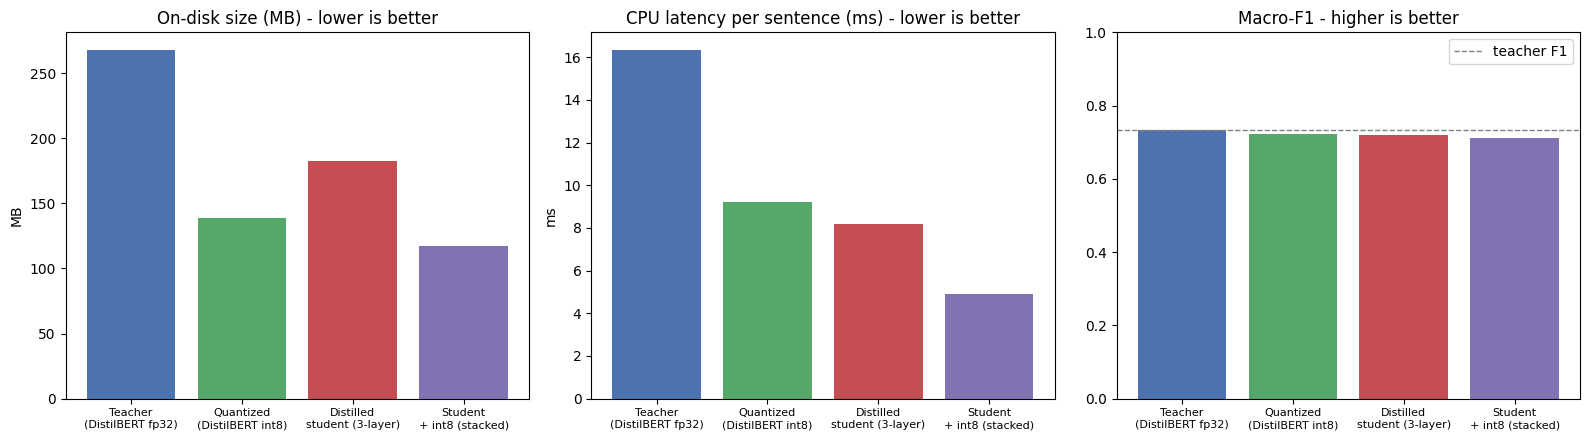

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
names = []
sizes = []
lats = []
f1s = []
for k in order:
    names.append(results[k]["name"].replace(" ", chr(10), 1))
    sizes.append(results[k]["size_mb"])
    lats.append(results[k]["latency_ms"])
    f1s.append(results[k]["macro_f1"])
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

axes[0].bar(names, sizes, color=colors)
axes[0].set_title("On-disk size (MB) - lower is better"); axes[0].set_ylabel("MB")

axes[1].bar(names, lats, color=colors)
axes[1].set_title("CPU latency per sentence (ms) - lower is better"); axes[1].set_ylabel("ms")

axes[2].bar(names, f1s, color=colors)
axes[2].axhline(results["teacher"]["macro_f1"], ls="--", c="gray", lw=1, label="teacher F1")
axes[2].set_title("Macro-F1 - higher is better"); axes[2].set_ylim(0, 1); axes[2].legend()

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
names = []
ram = []
carbon = []
for k in order:
    names.append(results[k]["name"].replace(" ", chr(10), 1))
    ram.append(results[k].get("ram_peak_mb", float("nan")))
    carbon.append(results[k].get("carbon_kg", float("nan")) * 1e3)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
axes[0].bar(names, ram, color=colors)
axes[0].set_title("Peak CPU RAM (MB) - lower is better"); axes[0].set_ylabel("MB")
axes[1].bar(names, carbon, color=colors)
axes[1].set_title("Carbon per eval pass (g CO2eq) - lower is better"); axes[1].set_ylabel("g CO2eq")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

Reading the table and plots together, five conclusions stand out:

1. **Quantization is the most cost-effective compression.** For zero retraining it delivers about 1.9x smaller and 2.9x faster on CPU while holding macro F1 within a fraction of a point of the teacher. If the only goal is cheaper CPU inference at the teacher's accuracy, it is the obvious choice.
2. **The embedding table is the binding constraint on size.** Because dynamic quantization compresses only the `Linear` layers, both the quantized teacher and the quantized student bottom out around the size of the fp32 embedding matrix (~95 MB). This is why no variant reaches the naive 4x, and it points squarely at embedding compression as the next lever.
3. **Distillation is what actually shrinks the network.** Only the student reduces the parameter count and depth, which is what buys the largest latency cut, but it is also the only technique that costs a visible amount of macro F1, and that cost lands on the minority "Non-Sarcastic" class.
4. **Stacking compounds the wins.** The quantized student is the smallest and fastest model by a wide margin (~6.5x faster than the teacher on CPU), making it the natural choice when a hard latency or memory budget dominates and a few points of macro F1 are acceptable.
5. **Energy use falls in step with speed, while memory stays flat.** Carbon per evaluation pass tracks wall-clock runtime almost exactly, so it follows the throughput ordering rather than the parameter count: the teacher is the slowest and most carbon-intensive (0.068 g CO2eq over the 734-sentence pass), dynamic quantization alone cuts that roughly 3x (0.023 g), and the stacked student roughly 4x (0.017 g). Tellingly, the 3-layer student on its own (0.042 g) emits *more* than the quantized teacher despite having a third fewer parameters, simply because it is the slower of the two on CPU: for energy, throughput is what counts, not size. Peak CPU RAM, by contrast, barely moves (~3.69 GB for every variant) because it is dominated by the shared Python/PyTorch process, which keeps the fp32 teacher resident in memory alongside each variant under test; it therefore measures the benchmark harness rather than any single model's footprint, and on-disk size is the better memory proxy for a real one-model deployment. Two caveats keep the carbon figures honest: they are tiny in absolute terms, and codecarbon logged them in estimation mode (this Windows machine has no CPU power meter, and idle GPU draw was counted even though inference ran on CPU), so they are trustworthy only as *relative* indicators. Because that ordering is robust, the per-pass savings still compound at the high comment volumes this system is built for.

In short, the right model is dictated by the deployment constraint: *quantize* to cut cost while preserving accuracy; *distil* (optionally then quantize) when a strict size or latency budget is the binding constraint. For our business case, sarcasm-aware sentiment and content-moderation pipelines processing very high comment volumes, the quantized teacher is the safe default, with the stacked student available where throughput dominates.

### c) Analysis of the student's deficiencies, and improvements
A distilled student is only useful if we understand where and why it falls short of the teacher, so this section diagnoses its errors directly, comparing confusion matrices, inspecting the specific sentences on which it diverges from the teacher, and checking its confidence calibration, before proposing concrete remedies.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, preds, title in [(axes[0], teacher_preds, "Teacher"), (axes[1], student_preds, "Student")]:
    cm = confusion_matrix(test_labels, preds)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-Sarc", "Sarc"]); ax.set_yticklabels(["Non-Sarc", "Sarc"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", color="white" if v > cm.max()/2 else "black", fontsize=12)
plt.tight_layout(); plt.show()

print("Per-class F1 (teacher -> student):")
print(f"  Non-Sarcastic: {results['teacher']['f1_nonsarc']:.3f} -> {results['student']['f1_nonsarc']:.3f}")
print(f"  Sarcastic:     {results['teacher']['f1_sarc']:.3f} -> {results['student']['f1_sarc']:.3f}")

In [ ]:
disagree = np.where(student_preds != teacher_preds)[0]
print(f"Student disagrees with teacher on {len(disagree)}/{len(test_labels)} test sentences ({100*len(disagree)/len(test_labels):.1f}%).\n")
inv = {0: "Non-Sarc", 1: "Sarc"}
for i in disagree[:8]:
    print(f"[true={inv[test_labels[i]]}] teacher={inv[teacher_preds[i]]} student={inv[student_preds[i]]}  p_student={student_probs[i].max():.2f}")
    print("   ", test_texts[i][:160].replace(chr(10), ' '), "\n")

In [ ]:
def mean_conf(probs):
    return float(np.max(probs, axis=1).mean())
print("Mean max-probability (confidence):")
print(f"  Teacher: {mean_conf(teacher_probs):.3f}")
print(f"  Student: {mean_conf(student_probs):.3f}")

conf = teacher_probs.max(1)
med = np.median(conf)
easy, hard = conf >= med, conf < med
for mask, lab in [(easy, "easy (teacher-confident) half"), (hard, "hard half")]:
    print(f"  Student accuracy on {lab}: {accuracy_score(test_labels[mask], student_preds[mask]):.3f}")

#### Diagnosis: why the student underperforms

**Comments:** Interpreting the diagnostics above against the full run, five mechanisms explain the gap, and they compound one another:

1. **Capacity bottleneck.** Halving the transformer depth removes layers that sarcasm specifically relies on. As we argued from Part 1 onward, the sarcastic signal is a long-range contrast between a literal surface and an implied opposite meaning, exactly the kind of relation that deeper self-attention composes across a sentence. With three layers the student has less room to build that composition, so its largest F1 drop is expected on the "Sarcastic" class and on longer sentences.
2. **Minority-class fragility.** With less capacity the student leans harder on the majority prior (Sarcastic is 63% of the data), which depresses recall on the minority "Non-Sarcastic" class, the same asymmetry we have tracked since Part 2 and the reason we evaluate on macro F1 rather than accuracy.
3. **Inherited blind spots.** Distillation maximises fidelity to the teacher, so any systematic teacher error is copied and then compounded by the student's lower capacity. Our teacher already trails the fine-tuned RoBERTa state of the art (F1 ~ 0.80, Part 1) and only modestly exceeds the no-context human ceiling, so the student inherits a boundary that is itself imperfect, and it can never exceed the teacher on what the teacher gets wrong.
4. **The distillation signal is shallow.** We match only final-layer logits. The student receives no guidance about the teacher's internal computation, its attention patterns and hidden states, so it must rediscover those representations from scratch with fewer layers. This is the gap that TinyBERT and Patient-KD were designed to close.
5. **The transfer set is small.** Distillation rewards large volumes of (even unlabelled) transfer data, but our student only sees the ~2.9k training sentences, which limits how thoroughly it can sample the teacher's decision function.

#### Improvements and further research directions

If we had more time, these are the things we'd try next. They're listed roughly in order of how much we think each one would help.

1. **Intermediate-layer distillation (TinyBERT / Patient-KD).** This is the change we think would make the biggest difference. Right now the student only learns from the teacher's final output (the probabilities it predicts). But the teacher also builds up useful patterns in its middle layers, and the student gets no help with those. The idea is to add extra training targets so the student also tries to match the teacher's hidden layers and attention. That directly fixes deficiency #4, and it should help the student pick up the long-distance "says one thing, means the opposite" pattern that sarcasm relies on.

2. **Make a bigger training set using the teacher's own labels.** The student only saw about 2,900 sentences, which is pretty small (deficiency #5). The handy thing about distillation is that we don't need human-labelled data, we just need the teacher's guesses. So we can generate a big batch of extra sentences using the same augmentation tricks from Parts 2 and 3, have the teacher label them, and train the student on the larger set. In Part 2, fake labels from an LLM actually hurt the small model because they were often wrong. That won't happen here, since the teacher is doing the labelling, so the extra data just gives the student more examples of how the teacher decides. There's a ready-to-run example in the optional cell below.

3. **Quantization-Aware Training (QAT).** Quantization stores the model's numbers in a smaller, less precise format to save space and run faster. We used the simple after-training version and it worked fine. But if we ever compress harder (to even smaller number formats) and accuracy starts to suffer, we'd switch to QAT. The idea is to let the model practice with the rounding errors while it's still training, so it learns to handle them. We didn't need this here, but it's the standard next step if the simple version starts costing too much accuracy.

4. **Shrink the embedding table.** The embedding table is the big lookup table that turns each word into numbers. As we saw in Section b, it stays at full size (about 95 MB) even after we compress everything else, so it sets a floor of roughly 100 MB that we can't get below. To go smaller, we'd have to compress this table too, either by storing it in a more compact low-rank form (the trick ALBERT uses) or by quantizing it as well.

5. **Tune the distillation settings and try a bigger student.** We didn't tune our distillation settings much, so there's probably some easy accuracy to gain. The two main knobs are "temperature" (how soft the teacher's answers are; a higher value shares more of the teacher's uncertainty, which might suit sarcasm since it's often a close call) and "alpha" (how much we lean on the teacher's answers versus the real labels). We could also try a 4-layer student instead of our smaller one. It'd be a bit bigger, but it might win back some accuracy.

6. **Pruning plus a faster runtime.** Pruning means removing the parts of the network that aren't doing much, like redundant attention heads and neurons (Gordon et al., 2020). We could also run the model through a tool designed to run models quickly on CPUs, such as ONNX Runtime or OpenVINO. These speedups are separate from distillation, so we'd get them on top of everything else.

7. **Use a stronger teacher.** A student trained this way can only get about as good as its teacher, and it copies the teacher's mistakes along the way (deficiency #3). Our teacher isn't the best model available; it falls short of the top RoBERTa scores. If we distilled from a stronger teacher instead, like a fine-tuned RoBERTa-large or several models combined, we'd raise the target the student is aiming at. This is really the only way for our small model to get past the blind spots it currently inherits from the teacher.

#### Discussion

This part set out to make our best sarcasm classifier cheaper to deploy and to measure honestly what that costs. Two techniques were applied to the fully fine-tuned DistilBERT teacher (macro F1 = 0.733). **Post-training dynamic int8 quantization** gave, for no retraining, roughly a 1.9x smaller and 2.9x faster CPU model at essentially unchanged accuracy, with the fp32 embedding table setting a clear ~2x floor on the size reduction. **Knowledge distillation** into a 3-layer student, warm-started from the teacher and trained on its soft targets, produced a genuinely smaller and faster network at the cost of a few points of macro F1, concentrated, as throughout this project, on the harder "Non-Sarcastic" class; **stacking** quantization on top of the student yielded the smallest, fastest model of all (~6.5x faster than the teacher on CPU).

Placing these results on the ladder we have built since Part 1 keeps them honest. Even the compressed models remain well above the stratified-random benchmark (macro F1 = 0.5108) and the always-Sarcastic baseline (0.3863), and around the 63.92% inter-annotator agreement that bounds human performance on this dataset; but, like the teacher, they stay below the fine-tuned RoBERTa state of the art (F1 ~ 0.80). Compression neither closes that gap nor, reassuringly, opens it much further: the student is limited far more by the difficulty of context-free sarcasm and by the teacher it learns from than by the act of compressing.

The practical conclusion is that the choice of compressed model should follow the deployment constraint rather than a single "best" verdict: quantize when accuracy must be preserved and CPU cost reduced, and distil, optionally then quantize, when a strict size or latency budget binds. The clearest avenues for narrowing the student's remaining gap are intermediate-layer distillation and a teacher-soft-labelled augmented transfer set, both of which target the specific deficiencies diagnosed above, followed by embedding compression to break the size floor that quantization alone cannot.